# ReFED US Food Surplus — EDA
US food surplus by sector, 2025 (ReFED).

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#edeff2", "axes.edgecolor": "#d4d8de",
    "font.size": 11,
})
ACCENT, MUTED = "#2f6fb0", "#c5cad2"

def quick_look(df, name):
    print(f"== {name} ==  shape = {df.shape}")
    display(df.head())
    print("dtypes:\n", df.dtypes, sep="")
    print("missing per column:", df.isna().sum().to_dict())
    num = df.select_dtypes("number").columns.tolist()
    print("numerical:", num)
    print("categorical:", [c for c in df.columns if c not in num])

refed = pd.read_excel("data/ReFED_surplus_table(Surplus Data).xlsx", sheet_name=0)
refed = refed[refed["Sector"].isin(["Residential","Farm","Manufacturing","Foodservice","Retail"])].copy()
SUR = [c for c in refed.columns if "Surplus" in str(c)][0]
GHG = [c for c in refed.columns if "GHG" in str(c)][0]
refed["co2e_per_ton"] = refed[GHG] / refed[SUR]
quick_look(refed, "ReFED surplus")

== ReFED surplus ==  shape = (5, 6)


,Sector,Surplus (M tons),% of total,GHG (MMt CO₂e),Value ($B),co2e_per_ton
0,Residential,23.50,33.2%,100.00,141.0,4.255319
1,Farm,16.90,23.9%,3.56,13.4,0.210651
2,Manufacturing,13.20,18.6%,38.60,42.7,2.924242
3,Foodservice,12.50,17.7%,63.60,157.0,5.088000
4,Retail,4.63,6.5%,15.10,30.3,3.261339


dtypes:
Sector                  str
Surplus (M tons)    float64
% of total              str
GHG (MMt CO₂e)      float64
Value ($B)          float64
co2e_per_ton        float64
dtype: object
missing per column: {'Sector': 0, 'Surplus (M tons)': 0, '% of total': 0, 'GHG (MMt CO₂e)': 0, 'Value ($B)': 0, 'co2e_per_ton': 0}
numerical: ['Surplus (M tons)', 'GHG (MMt CO₂e)', 'Value ($B)', 'co2e_per_ton']
categorical: ['Sector', '% of total']


In [13]:
df.describe().round(2)

,Surplus (M tons),GHG (MMt CO₂e),Value ($B)
count,5.00,5.00,5.00
mean,14.15,44.17,76.88
std,6.88,38.79,66.89
min,4.63,3.56,13.40
25%,12.50,15.10,30.30
50%,13.20,38.60,42.70
75%,16.90,63.60,141.00
max,23.50,100.00,157.00


### Visualization — which sectors generate the most surplus

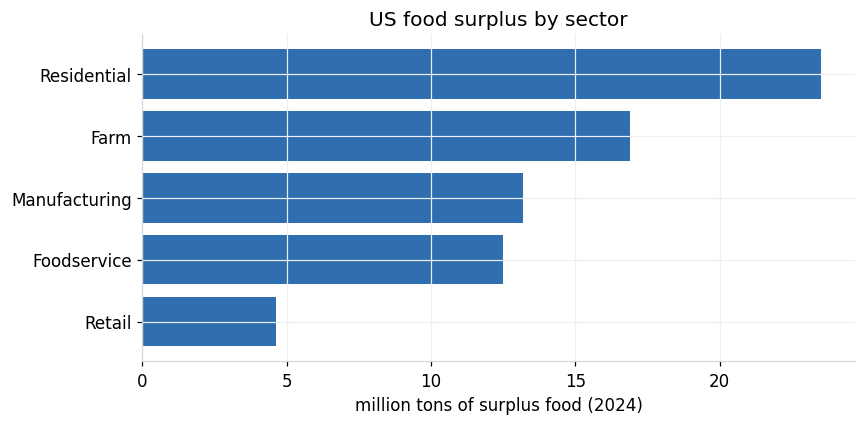

In [14]:
d = df.sort_values("Surplus (M tons)")

plt.figure(figsize=(8, 4))
plt.barh(d["Sector"], d["Surplus (M tons)"], color="#2f6fb0")
plt.xlabel("million tons of surplus food (2024)")
plt.title("US food surplus by sector")
plt.tight_layout()
plt.show()

**Takeaway:** homes generate the most surplus (~23.5M tons, a third of the US total of 70.7M), ahead of farms, manufacturing, and foodservice.

### The tonnage-vs-carbon flip

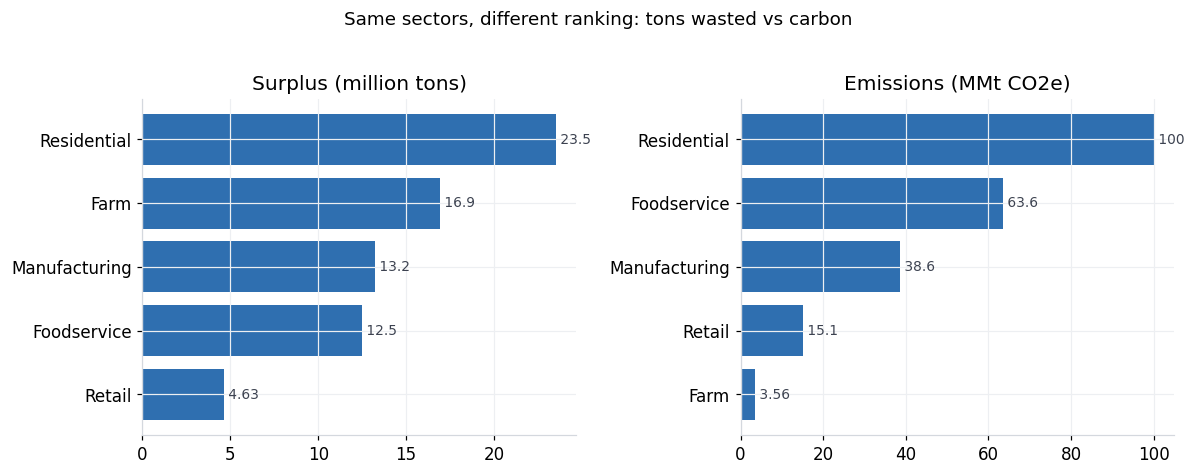

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, col, title in [(axes[0], SUR, "Surplus (million tons)"),
                       (axes[1], GHG, "Emissions (MMt CO2e)")]:
    d = refed.sort_values(col)
    ax.barh(d["Sector"], d[col], color=ACCENT)
    for y, v in enumerate(d[col]):
        ax.text(v, y, f" {v:g}", va="center", ha="left", fontsize=9, color="#3c4250")
    ax.set_title(title)
fig.suptitle("Same sectors, different ranking: tons wasted vs carbon", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

**Carbon intensity** — CO2e per ton of surplus, by sector (later-chain waste carries more emissions).

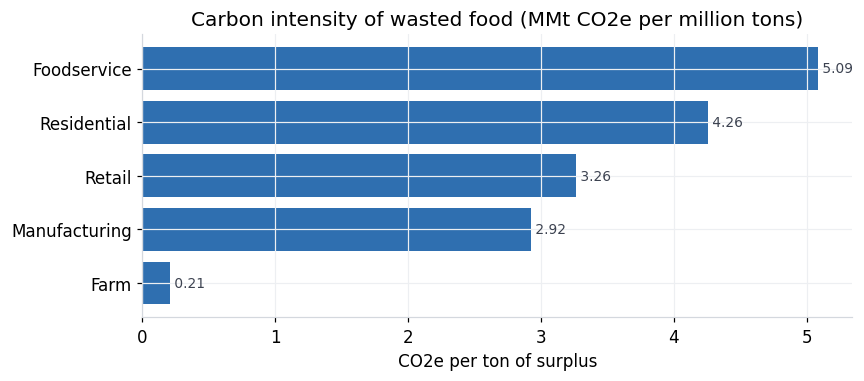

In [17]:
d = refed.sort_values("co2e_per_ton")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(d["Sector"], d["co2e_per_ton"], color=ACCENT)
for y, v in enumerate(d["co2e_per_ton"]):
    ax.text(v, y, f" {v:.2f}", va="center", ha="left", fontsize=9, color="#3c4250")
ax.set_title("Carbon intensity of wasted food (MMt CO2e per million tons)")
ax.set_xlabel("CO2e per ton of surplus")
plt.tight_layout(); plt.show()

### ReFED — findings
- By tonnage: Residential > Farm > Manufacturing > Foodservice > Retail.
- By carbon: Residential > Foodservice > Manufacturing > Retail > Farm — Farm drops from 2nd to last.
- Carbon per ton: Foodservice (~5.1) and Residential (~4.3) are ~20-25x Farm (~0.2) — food wasted later in the chain is far heavier in carbon.
- SB 1383 targets the business tiers (retail/foodservice), which sit high on carbon-per-ton.